# Plant Disease Detection
# Data Exploration Notebook

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

In [2]:
TRAIN_DIR = "../dataset/train"
VALID_DIR = "../dataset/valid"

In [5]:
import os

classes = []

for item in os.listdir(TRAIN_DIR):

    full_path = os.path.join(TRAIN_DIR, item)

    if os.path.isdir(full_path):
        classes.append(item)

classes = sorted(classes)

print(f"Total Classes: {len(classes)}")

Total Classes: 38


In [6]:
for item in os.listdir(TRAIN_DIR):
    print(item)

.DS_Store
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy
Corn_(maize)___Northern_Leaf_Blight
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___healthy
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___healthy
Potato___Late_blight
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___healthy
Strawberry___Leaf_scorch
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___healthy
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_mosaic_virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [7]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(TRAIN_DIR, cls)

    class_counts[cls] = len(
        os.listdir(class_path)
    )

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

df.head()

,Class,Count
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


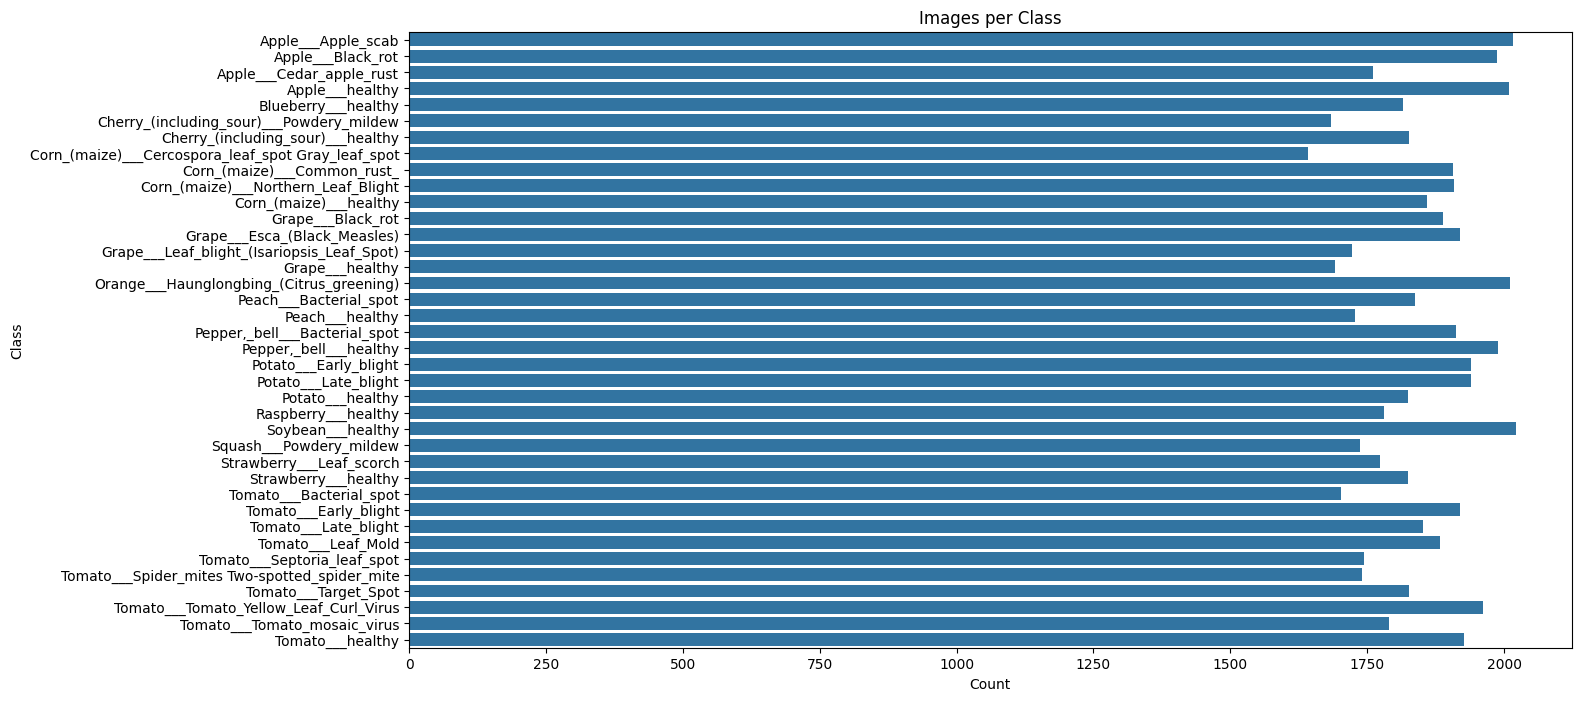

In [8]:
plt.figure(figsize=(15,8))

sns.barplot(
    data=df,
    x="Count",
    y="Class"
)

plt.title("Images per Class")
plt.show()

In [9]:
print("Total Classes:", len(classes))

print(
    "Total Training Images:",
    df["Count"].sum()
)

Total Classes: 38
Total Training Images: 70295


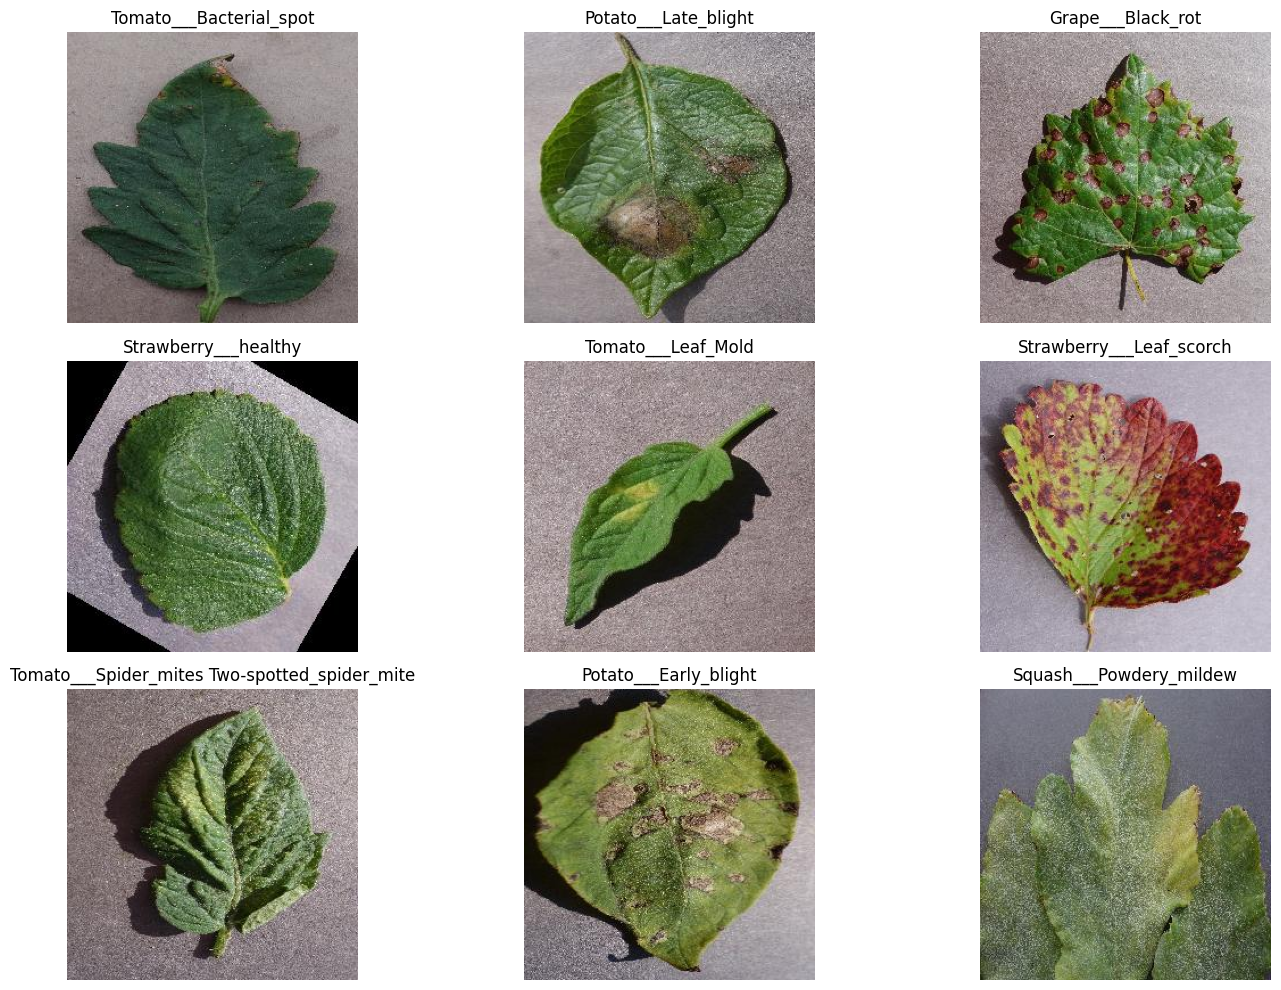

In [10]:
import random

plt.figure(figsize=(15,10))

for i in range(9):

    cls = random.choice(classes)

    img_name = random.choice(
        os.listdir(
            os.path.join(TRAIN_DIR, cls)
        )
    )

    img_path = os.path.join(
        TRAIN_DIR,
        cls,
        img_name
    )

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
widths = []
heights = []

for cls in classes:

    class_path = os.path.join(
        TRAIN_DIR,
        cls
    )

    images = os.listdir(class_path)

    for image in images[:50]:

        path = os.path.join(
            class_path,
            image
        )

        img = Image.open(path)

        widths.append(img.size[0])
        heights.append(img.size[1])

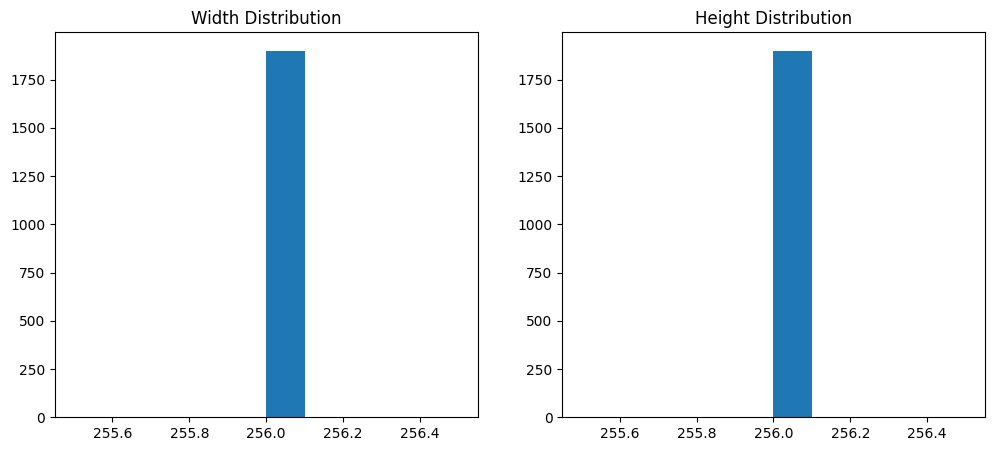

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(widths)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights)
plt.title("Height Distribution")

plt.show()

In [13]:
corrupted = []

for cls in classes:

    class_path = os.path.join(
        TRAIN_DIR,
        cls
    )

    for img_name in os.listdir(class_path):

        try:

            path = os.path.join(
                class_path,
                img_name
            )

            img = Image.open(path)

            img.verify()

        except:

            corrupted.append(path)

print(
    "Corrupted Images:",
    len(corrupted)
)

Corrupted Images: 0


In [14]:
healthy = 0
diseased = 0

for cls in classes:

    count = len(
        os.listdir(
            os.path.join(
                TRAIN_DIR,
                cls
            )
        )
    )

    if "healthy" in cls.lower():
        healthy += count
    else:
        diseased += count

print("Healthy:", healthy)
print("Diseased:", diseased)

Healthy: 22294
Diseased: 48001


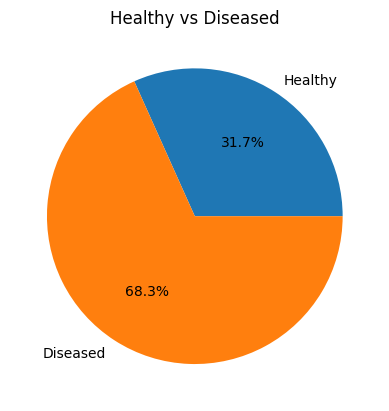

In [15]:
plt.pie(
    [healthy,diseased],
    labels=[
        "Healthy",
        "Diseased"
    ],
    autopct="%1.1f%%"
)

plt.title(
    "Healthy vs Diseased"
)

plt.show()

In [16]:
plants = []

for cls in classes:

    plant = cls.split("___")[0]

    plants.append(plant)

species_count = Counter(plants)

species_count

Counter({'Tomato': 10,
         'Apple': 4,
         'Corn_(maize)': 4,
         'Grape': 4,
         'Potato': 3,
         'Cherry_(including_sour)': 2,
         'Peach': 2,
         'Pepper,_bell': 2,
         'Strawberry': 2,
         'Blueberry': 1,
         'Orange': 1,
         'Raspberry': 1,
         'Soybean': 1,
         'Squash': 1})

In [17]:
species_df = pd.DataFrame(
    species_count.items(),
    columns=[
        "Plant",
        "Disease Classes"
    ]
)

species_df

,Plant,Disease Classes
0,Apple,4
1,Blueberry,1
2,Cherry_(including_sour),2
3,Corn_(maize),4
4,Grape,4
5,Orange,1
6,Peach,2
7,"Pepper,_bell",2
8,Potato,3
9,Raspberry,1


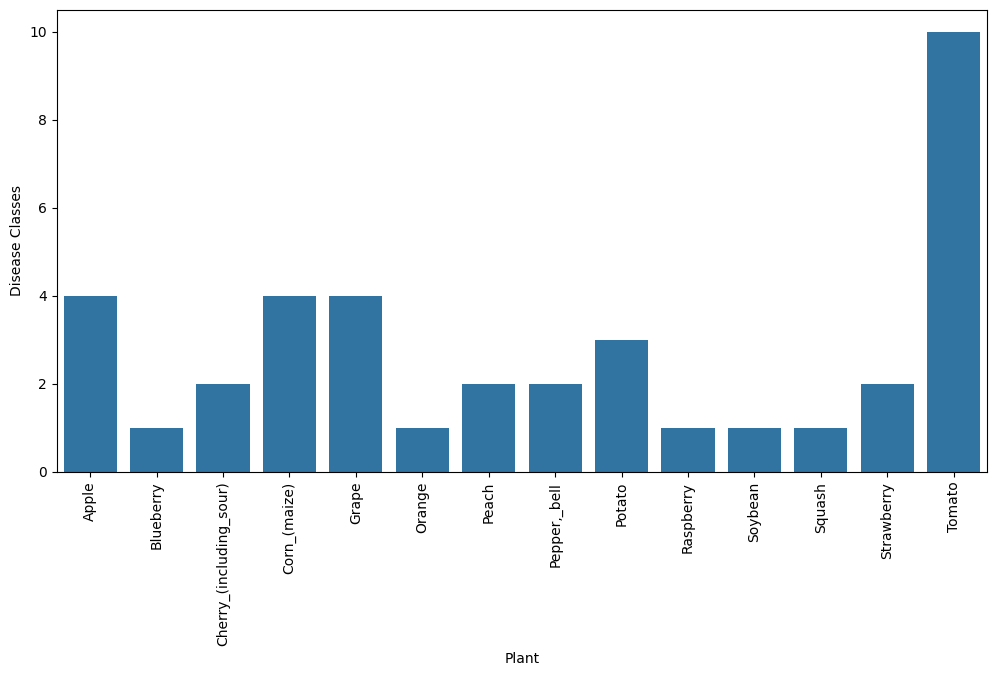

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=species_df,
    x="Plant",
    y="Disease Classes"
)

plt.xticks(rotation=90)

plt.show()

## Findings

1. Dataset contains 38 disease classes.
2. Classes are reasonably balanced.
3. No corrupted images detected.
4. Most images have similar dimensions.
5. Dataset includes multiple crops:
   - Apple
   - Tomato
   - Potato
   - Corn
   - Grape
   etc.
6. Image resizing to 128×128 is appropriate.
7. Dataset is suitable for CNN training.